In [53]:
!pip install google-generativeai

In [54]:
!pip install groq

In [55]:
import pandas as pd
import numpy as np
import json
import time
import os
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from groq import Groq

In [ ]:
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if GROQ_API_KEY == "your_api_key_here":
    raise ValueError("⚠️ Please set your GROQ_API_KEY!")

try:
    client = Groq(api_key=GROQ_API_KEY)
    print("✅ Groq client initialized")
except Exception as e:
    raise ValueError(f"❌ Failed to initialize Groq: {e}")

MODEL_NAME = "llama-3.1-8b-instant"
SAMPLE_SIZE = 200
DELAY_BETWEEN_REQUESTS = 9.0
MAX_RETRIES = 6
BASE_RETRY_DELAY = 10
MAX_REVIEW_LENGTH = 220  # Increased for more context
MAX_RESPONSE_TOKENS = 350  # More room for detailed reasoning

✅ Groq client initialized


In [57]:
def ultra_enhanced_prompt_v4(review_text):
    """
    MAXIMUM IMPROVEMENTS:
    - 6 comprehensive aspects (Food, Service, Value, Atmosphere, Cleanliness, Wait Time)
    - 0-10 granular scoring for each aspect
    - Real Yelp dataset examples for each rating level
    - Explicit superlative and rage detection
    - Smart truncation preserving conclusions
    - Multi-step reasoning chain
    - Temperature 0.6 for diversity
    """

    if not isinstance(review_text, str):
        review_text = str(review_text)

    review_text = review_text.strip()
    review_text = re.sub(r'\s+', ' ', review_text)

    # SMART TRUNCATION: Keep beginning (60%) + ending (40%)
    words = review_text.split()
    if len(words) > MAX_REVIEW_LENGTH:
        first_part_len = int(MAX_REVIEW_LENGTH * 0.6)
        last_part_len = MAX_REVIEW_LENGTH - first_part_len

        first_part = ' '.join(words[:first_part_len])
        last_part = ' '.join(words[-last_part_len:])
        review_short = f"{first_part} [...] {last_part}"
    else:
        review_short = review_text

    # JSON safety
    review_short = review_short.replace('"', "'").replace('\n', ' ').replace('\r', '')

    prompt = f"""You are an expert Yelp rating analyst. Rate this review 1-5 stars using comprehensive aspect analysis.

REVIEW TO RATE:
"{review_short}"

╔═══════════════════════════════════════════════════════════════════════════╗
║                    STEP 1: ANALYZE ALL 6 ASPECTS                          ║
║                    Score each aspect 0-10 (10=perfect, 0=terrible)        ║
╚═══════════════════════════════════════════════════════════════════════════╝

**1. FOOD QUALITY** (0-10 or "not mentioned"):
   Positive signals: delicious, amazing, incredible, best, perfect, fresh, flavorful,
                     tasty, mouth-watering, exceptional, phenomenal
   Negative signals: terrible, disgusting, awful, horrible, bland, stale, cold,
                     undercooked, overcooked, inedible, gross, nasty
   Score: ___/10

**2. SERVICE QUALITY** (0-10 or "not mentioned"):
   Positive signals: excellent, attentive, friendly, quick, helpful, accommodating,
                     professional, warm, welcoming, knowledgeable, courteous
   Negative signals: rude, slow, terrible, ignored, unprofessional, dismissive,
                     inattentive, took forever, no service, horrible staff
   Score: ___/10

**3. VALUE/PRICE** (0-10 or "not mentioned"):
   Positive signals: worth it, great value, reasonable, affordable, fair prices,
                     good deal, bang for your buck, well-priced
   Negative signals: overpriced, expensive, rip-off, not worth it, too pricey,
                     highway robbery, waste of money, ridiculously expensive
   Score: ___/10

**4. ATMOSPHERE/AMBIANCE** (0-10 or "not mentioned"):
   Positive signals: beautiful, cozy, great ambiance, nice decor, comfortable,
                     lovely setting, perfect atmosphere, charming, inviting
   Negative signals: noisy, cramped, uncomfortable, ugly, depressing, dingy,
                     dated decor, unpleasant atmosphere, too loud, chaotic
   Score: ___/10

**5. CLEANLINESS/HYGIENE** (0-10 or "not mentioned"):
   Positive signals: clean, spotless, immaculate, well-maintained, sanitary, pristine
   Negative signals: dirty, filthy, grimy, unsanitary, disgusting, unhygienic,
                     sticky tables, gross bathrooms, roaches, health hazard
   Score: ___/10

**6. WAIT TIME/EFFICIENCY** (0-10 or "not mentioned"):
   Positive signals: fast, quick, prompt, efficient, no wait, timely, speedy
   Negative signals: slow, took forever, waited too long, unreasonably long wait,
                     hour wait, terrible wait times, forever to get food
   Score: ___/10

╔═══════════════════════════════════════════════════════════════════════════╗
║              STEP 2: DETECT EXTREME SENTIMENT SIGNALS                     ║
╚═══════════════════════════════════════════════════════════════════════════╝

**🌟 5-STAR EXCELLENCE INDICATORS** (Check if ANY are present):
[ ] Superlatives: "best", "greatest", "most amazing", "ever had", "of my life"
[ ] Multiple exclamations: "!!!", "OMG!", "WOW!", "LOVE LOVE LOVE"
[ ] Perfection language: "flawless", "perfect", "couldn't be better", "exceeded expectations"
[ ] Strong recommendation: "must go", "everyone should try", "life-changing", "go here now"
[ ] Enthusiastic repetition: "so good so good", "amazing amazing", multiple praise words
[ ] All caps positive: "AMAZING", "BEST EVER", "INCREDIBLE"
[ ] ALL or MOST aspects scored 8-10/10

**💔 1-STAR TERRIBLE INDICATORS** (Check if 2+ are present):
[ ] Extreme negatives: "worst", "disgusting", "horrible", "awful", "terrible", "atrocious"
[ ] Strong warnings: "never again", "avoid at all costs", "DO NOT GO", "stay away", "warning"
[ ] All caps anger: "WORST", "TERRIBLE", "DISGUSTING", "HORRIBLE"
[ ] Health/safety concerns: "food poisoning", "sick", "health hazard", "roaches", "rats"
[ ] Multiple aspect failures: 3+ aspects scored 0-3/10
[ ] Profanity or extreme anger tone
[ ] Demanding refunds: "waste of money", "want my money back", "total rip-off"

╔═══════════════════════════════════════════════════════════════════════════╗
║                STEP 3: EVALUATE OVERALL RECOMMENDATION                    ║
╚═══════════════════════════════════════════════════════════════════════════╝

What is the reviewer's FINAL CONCLUSION?
• "Will definitely return" / "Can't wait to go back" / "New favorite" → STRONG POSITIVE (+2)
• "Would recommend" / "Worth a visit" / "I'll be back" → POSITIVE (+1)
• "It's okay" / "Might return" / No clear stance → NEUTRAL (0)
• "Disappointed" / "Won't return" / "Not recommended" → NEGATIVE (-1)
• "Never again" / "Avoid" / "Warning others" → STRONG NEGATIVE (-2)

╔═══════════════════════════════════════════════════════════════════════════╗
║                  STEP 4: APPLY RATING DECISION RULES                      ║
╚═══════════════════════════════════════════════════════════════════════════╝

**5★ = EXCEPTIONAL/OUTSTANDING** (Don't be stingy with genuine excellence!)
CONDITIONS:
✓ Has 2+ "5-star excellence indicators" from Step 2
✓ ALL or MOST aspects (4+) scored 8-10/10
✓ Strong positive recommendation (+2)
✓ Little to no criticism

REAL EXAMPLES FROM YELP:
• "This place is absolutely AMAZING! Best tacos I've had in my entire life. The carne asada
  was perfectly seasoned, the salsa was fresh and flavorful, and the service was outstanding.
  Our waiter was so attentive and friendly. Prices are very reasonable for the quality.
  Can't wait to come back! Everyone needs to try this place!" → 5★

• "WOW!! Exceeded all expectations. Food was phenomenal - every single dish was cooked to
  perfection. Service was impeccable, atmosphere was beautiful, and the value was incredible.
  New favorite restaurant hands down. Will be returning weekly!" → 5★

**4★ = GOOD/SOLID** (Positive overall with minor flaws)
CONDITIONS:
✓ MOST aspects (3-5) scored 6-9/10
✓ Positive recommendation (+1) or would return
✓ Minor complaints present but don't outweigh positives
✓ Uses words like "really good", "great", "enjoyed"

REAL EXAMPLES FROM YELP:
• "Really good pizza and the staff was super friendly. The atmosphere is nice and cozy.
  Only complaint is it's a bit pricey - $18 for a personal pizza seems steep. But the
  quality is there, so I'd still come back." → 4★

• "Great food and excellent service! My pasta was delicious and perfectly cooked. Our
  server was very attentive. The only downside was the wait time - we waited about
  40 minutes for a table even with a reservation. Still worth it though!" → 4★

• "Amazing food, great service!" + "will return" → 4★

**3★ = AVERAGE/OKAY/MIXED** (Neither good nor bad, or balanced pros/cons)
CONDITIONS:
✓ Mixed aspect scores (some 4-6, some 7-8/10) OR all aspects scored 5-6/10
✓ Neutral language: "okay", "decent", "fine", "nothing special", "average"
✓ No strong feelings either way (0 recommendation)
✓ Equal positives and negatives mentioned

REAL EXAMPLES FROM YELP:
• "It's okay. Nothing really stood out as great or terrible. The food was decent, service
  was fine, prices were average. Just a very middle-of-the-road experience. Not sure if
  I'll go back - there are other options in the area." → 3★

• "Food was okay - not bad but nothing special. The burger was decent but pretty basic.
  Service was fine, nothing to complain about but nothing impressive either. Prices are
  reasonable. It's an okay spot if you're in the area." → 3★

• "Food okay, nothing special" + neutral → 3★

**2★ = POOR/DISAPPOINTING** (Multiple problems, negative overall)
CONDITIONS:
✓ MOST aspects (3-5) scored 2-5/10
✓ Multiple specific complaints mentioned
✓ Negative recommendation (-1) or wouldn't return
✓ Uses words like "disappointed", "not good", "poor", "subpar"

REAL EXAMPLES FROM YELP:
• "Pretty disappointing experience overall. Food took forever to arrive and when it did,
  it was cold. My steak was overcooked and dry. Service was inattentive - had to flag
  down the waiter multiple times. For the price, expected much better. Won't be returning." → 2★

• "Not impressed. The food was mediocre at best - bland and uninspired. Service was slow
  and our orders were wrong. Place was also pretty dirty - sticky tables and messy floors.
  Would not recommend." → 2★

• "Food cold, service slow" + "disappointed" → 2★

**1★ = TERRIBLE/WORST** (Extreme problems, angry, warning others)
CONDITIONS:
✓ Has 2+ "1-star terrible indicators" from Step 2
✓ MULTIPLE aspects (3+) scored 0-3/10
✓ Strong negative recommendation (-2)
✓ Extreme language, anger, or health/safety concerns

REAL EXAMPLES FROM YELP:
• "WORST restaurant I have EVER been to. The food was absolutely DISGUSTING - I couldn't
  even finish it. Found a hair in my pasta. Service was terrible, staff was rude and
  dismissive. The place was filthy - dirty tables, gross bathrooms. Complete waste of money.
  AVOID AT ALL COSTS!!!" → 1★

• "Horrible experience from start to finish. Food was cold, tasted awful, and I got food
  poisoning later that night. Service was the worst - waited 30 minutes just to get water.
  Place was dirty and smelled bad. Never again. Do yourself a favor and go anywhere else.
  This place should be shut down!" → 1★

• "Terrible everything" + "never again" → 1★

╔═══════════════════════════════════════════════════════════════════════════╗
║                    ⚠️ CRITICAL ANTI-BIAS REMINDERS ⚠️                     ║
╚═══════════════════════════════════════════════════════════════════════════╝

🚫 DON'T default to 4★! Not every review is 4 stars.
🚫 DON'T soften extreme negatives! If they're furious → give 1★
🚫 DON'T over-inflate mediocre reviews! "Decent/okay" = 3★, NOT 4★
✅ DO give 5★ to genuinely exceptional experiences (don't be stingy!)
✅ DO give 1★ to truly terrible experiences (don't soften)
✅ DO use the full 1-5 scale, not just 3-4★

REMEMBER:
• "Good but..." usually = 4★ (not 3★)
• "Decent"/"okay"/"fine"/"nothing special" = 3★ (not 4★)
• Multiple "!" and "best ever" = 5★ (not 4★)
• Multiple complaints + "never again" = 1★ (not 2★)

╔═══════════════════════════════════════════════════════════════════════════╗
║                         FINAL DECISION                                    ║
╚═══════════════════════════════════════════════════════════════════════════╝

Based on:
1. Your aspect scores (Step 1)
2. Extreme sentiment signals (Step 2)
3. Overall recommendation (Step 3)
4. Rating rules (Step 4)

Respond with ONLY this JSON format (no other text):
{{"predicted_stars": 4, "explanation": "Brief reasoning mentioning key aspects and sentiment"}}"""

    return prompt

In [58]:
def call_api_robust(prompt, request_num=0):
    """API call with TEMPERATURE = 0.6 for maximum diversity"""

    for attempt in range(MAX_RETRIES):
        try:
            response = client.chat.completions.create(
                messages=[{"role": "user", "content": prompt}],
                model=MODEL_NAME,
                temperature=0.6,  # ← INCREASED to 0.6 for diversity!
                max_tokens=MAX_RESPONSE_TOKENS,
            )

            text = response.choices[0].message.content.strip()

            # Strategy 1: Clean JSON extraction
            if '{' in text and '}' in text:
                start = text.find('{')
                end = text.rfind('}') + 1
                json_str = text[start:end]
                json_str = json_str.replace('\n', ' ').replace('\r', '')
                json_str = re.sub(r'\s+', ' ', json_str)

                try:
                    result = json.loads(json_str)
                except:
                    json_str = json_str.replace("'", '"')
                    json_str = re.sub(r',(\s*[}\]])', r'\1', json_str)
                    result = json.loads(json_str)

                rating = None
                for key in ['predicted_stars', 'stars', 'rating']:
                    if key in result:
                        rating = int(result[key])
                        break

                explanation = None
                for key in ['explanation', 'reason', 'reasoning']:
                    if key in result:
                        explanation = str(result[key])
                        break

                if rating and 1 <= rating <= 5:
                    return {
                        'success': True,
                        'predicted_stars': rating,
                        'explanation': explanation or "No explanation"
                    }

            # Strategy 2: Regex extraction
            stars_match = re.search(r'(?:predicted_stars|stars|rating)[\"\']?\s*:\s*(\d)', text)
            if stars_match:
                rating = int(stars_match.group(1))
                if 1 <= rating <= 5:
                    expl_match = re.search(r'(?:explanation|reason)[\"\']?\s*:\s*[\"\']([^\"\']+)', text)
                    explanation = expl_match.group(1) if expl_match else "Extracted via regex"
                    return {
                        'success': True,
                        'predicted_stars': rating,
                        'explanation': explanation
                    }

            if attempt < MAX_RETRIES - 1:
                print(f"\n⚠️ Req #{request_num}, attempt {attempt+1}: Invalid response, retrying...")
                time.sleep(3)
                continue

            return {
                'success': False,
                'error': 'Could not parse response',
                'raw': text[:200]
            }

        except Exception as e:
            error_str = str(e)

            if '429' in error_str or 'rate limit' in error_str.lower():
                wait = BASE_RETRY_DELAY * (2 ** attempt)
                print(f"\n⚠️ Rate limit! Waiting {wait}s... (attempt {attempt+1}/{MAX_RETRIES})")
                time.sleep(wait)
                continue

            if attempt < MAX_RETRIES - 1:
                print(f"\n⚠️ Error: {error_str[:100]}, retrying...")
                time.sleep(5)
                continue

            return {
                'success': False,
                'error': error_str[:200],
                'raw': ''
            }

    return {'success': False, 'error': 'Max retries exceeded', 'raw': ''}

In [59]:
def evaluate_with_diagnostics(df, prompt_func, prompt_name, sample_size=200):
    """Evaluate with detailed error analysis"""

    print(f"\n{'='*80}")
    print(f"🎯 EVALUATING: {prompt_name}")
    print(f"{'='*80}")
    print(f"📊 Samples: {sample_size}")
    print(f"🌡️ Temperature: 0.6")
    print(f"⏱️ Delay: {DELAY_BETWEEN_REQUESTS}s")
    print(f"⏰ Est. time: ~{(sample_size * DELAY_BETWEEN_REQUESTS)/60:.1f}min")
    print(f"{'='*80}\n")

    df_sample = df.head(sample_size).copy().reset_index(drop=True)

    results = []
    metrics = {
        'correct': 0,
        'valid_json': 0,
        'total': sample_size,
        'actuals': [],
        'predicted': [],
        'off_by_1': 0,
        'off_by_2_plus': 0
    }

    error_patterns = {
        '5_as_4': 0, '5_as_3': 0, '5_as_2': 0, '5_as_1': 0,
        '4_as_5': 0, '4_as_3': 0, '4_as_2': 0, '4_as_1': 0,
        '3_as_5': 0, '3_as_4': 0, '3_as_2': 0, '3_as_1': 0,
        '2_as_5': 0, '2_as_4': 0, '2_as_3': 0, '2_as_1': 0,
        '1_as_5': 0, '1_as_4': 0, '1_as_3': 0, '1_as_2': 0
    }

    start_time = time.time()

    for idx in range(len(df_sample)):
        row = df_sample.iloc[idx]
        sample_num = idx + 1

        elapsed = time.time() - start_time
        eta = (elapsed / sample_num) * (sample_size - sample_num)
        acc = (metrics['correct'] / sample_num * 100) if sample_num > 0 else 0

        print(f"[{sample_num}/{sample_size}] "
              f"⏱️{elapsed/60:.1f}m | ETA ~{eta/60:.1f}m | "
              f"✓{metrics['correct']} | Acc:{acc:.1f}% | "
              f"Valid:{metrics['valid_json']}/{sample_num}",
              end='\r')

        try:
            prompt = prompt_func(row['text'])
        except Exception as e:
            results.append({
                'sample_id': sample_num,
                'actual': int(row['stars']),
                'predicted': None,
                'explanation': '',
                'valid': False,
                'error': f'Prompt error: {str(e)[:100]}'
            })
            continue

        response = call_api_robust(prompt, sample_num)

        result = {
            'sample_id': sample_num,
            'actual': int(row['stars']),
            'predicted': None,
            'explanation': '',
            'valid': response['success'],
            'error': response.get('error', '')
        }

        if response['success']:
            metrics['valid_json'] += 1
            predicted = response['predicted_stars']
            actual = int(row['stars'])

            result['predicted'] = predicted
            result['explanation'] = response['explanation']

            metrics['actuals'].append(actual)
            metrics['predicted'].append(predicted)

            if predicted == actual:
                metrics['correct'] += 1

            error_magnitude = abs(predicted - actual)
            if error_magnitude == 1:
                metrics['off_by_1'] += 1
            elif error_magnitude >= 2:
                metrics['off_by_2_plus'] += 1

            if predicted != actual:
                key = f'{actual}_as_{predicted}'
                if key in error_patterns:
                    error_patterns[key] += 1

        results.append(result)
        time.sleep(DELAY_BETWEEN_REQUESTS)

        if sample_num % 50 == 0:
            pd.DataFrame(results).to_csv(f'{prompt_name}_checkpoint_{sample_num}.csv', index=False)
            print(f"\n💾 Checkpoint saved at {sample_num}" + " "*50)

    print("\n")

    accuracy = (metrics['correct'] / metrics['valid_json'] * 100) if metrics['valid_json'] > 0 else 0
    json_rate = (metrics['valid_json'] / metrics['total']) * 100
    mae = sum([abs(a - p) for a, p in zip(metrics['actuals'], metrics['predicted'])]) / len(metrics['actuals']) if metrics['actuals'] else 0
    within_1 = ((metrics['correct'] + metrics['off_by_1']) / metrics['valid_json'] * 100) if metrics['valid_json'] > 0 else 0

    print(f"\n{'='*80}")
    print(f"✅ {prompt_name} - RESULTS")
    print(f"{'='*80}")
    print(f"🎯 Accuracy: {accuracy:.2f}% ({metrics['correct']}/{metrics['valid_json']})")
    print(f"📊 JSON Success: {json_rate:.1f}% ({metrics['valid_json']}/{metrics['total']})")
    print(f"📉 MAE: {mae:.2f} stars")
    print(f"🎲 Within 1 star: {within_1:.1f}%")
    print(f"⏱️ Time: {(time.time() - start_time)/60:.1f}min")
    print(f"🌡️ Temperature: 0.6")
    print(f"{'='*80}")

    print(f"\n📊 ERROR PATTERN ANALYSIS:")
    print(f"{'─'*80}")
    print(f"Baseline (Aspect_Based): 59.5% accuracy")
    print(f"Current: {accuracy:.2f}% accuracy")
    print(f"Improvement: {accuracy - 59.5:+.2f}%")
    print(f"{'─'*80}")
    top_errors = sorted(error_patterns.items(), key=lambda x: x[1], reverse=True)[:10]
    for pattern, count in top_errors:
        if count > 0:
            actual, predicted = pattern.split('_as_')
            print(f"   {actual}★ predicted as {predicted}★: {count} times")
    print(f"{'─'*80}\n")

    results_df = pd.DataFrame(results)
    results_df.to_csv(f'{prompt_name}_FINAL.csv', index=False)
    print(f"💾 Saved: {prompt_name}_FINAL.csv\n")

    return {
        'name': prompt_name,
        'accuracy': accuracy,
        'json_rate': json_rate,
        'mae': mae,
        'within_1': within_1,
        'actuals': metrics['actuals'],
        'predicted': metrics['predicted'],
        'results': results,
        'error_patterns': error_patterns
    }

In [60]:
def create_comparison_viz(metrics_list):
    """Create comprehensive comparison visualization"""

    print("\n📈 Creating visualization...")

    fig = plt.figure(figsize=(22, 16))
    gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

    fig.suptitle('Ultra-Enhanced Prompt Performance - 200 Samples',
                 fontsize=24, fontweight='bold')

    colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

    # 1. Accuracy Comparison
    ax1 = fig.add_subplot(gs[0, 0])
    names = [m['name'] for m in metrics_list]
    accs = [m['accuracy'] for m in metrics_list]
    bars = ax1.bar(range(len(names)), accs, color=colors[:len(names)],
                   alpha=0.8, edgecolor='black', linewidth=2)
    ax1.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=13)
    ax1.set_title('Accuracy Comparison', fontweight='bold', fontsize=15)
    ax1.set_xticks(range(len(names)))
    ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=11)
    ax1.set_ylim(0, 100)
    ax1.axhline(y=59.5, color='red', linestyle='--', linewidth=2,
                alpha=0.7, label='Baseline (59.5%)')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
    ax1.legend(fontsize=11)
    for bar, v in zip(bars, accs):
        improvement = v - 59.5
        color = 'green' if improvement > 0 else 'red'
        ax1.text(bar.get_x() + bar.get_width()/2, v + 2,
                f'{v:.1f}%\n({improvement:+.1f}%)',
                ha='center', fontweight='bold', fontsize=10, color=color)

    # 2. MAE Comparison
    ax2 = fig.add_subplot(gs[0, 1])
    maes = [m['mae'] for m in metrics_list]
    bars = ax2.bar(range(len(names)), maes, color=colors[:len(names)],
                   alpha=0.8, edgecolor='black', linewidth=2)
    ax2.set_ylabel('Mean Absolute Error', fontweight='bold', fontsize=13)
    ax2.set_title('MAE (Lower = Better)', fontweight='bold', fontsize=15)
    ax2.set_xticks(range(len(names)))
    ax2.set_xticklabels(names, rotation=45, ha='right', fontsize=11)
    ax2.axhline(y=0.44, color='red', linestyle='--', linewidth=2,
                alpha=0.7, label='Baseline (0.44)')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
    ax2.legend(fontsize=11)
    for bar, v in zip(bars, maes):
        improvement = 0.44 - v
        color = 'green' if improvement > 0 else 'red'
        ax2.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.3f}\n({improvement:+.3f})',
                ha='center', fontweight='bold', fontsize=10, color=color)

    # 3. Within 1 Star Accuracy
    ax3 = fig.add_subplot(gs[0, 2])
    within1 = [m['within_1'] for m in metrics_list]
    bars = ax3.bar(range(len(names)), within1, color=colors[:len(names)],
                   alpha=0.8, edgecolor='black', linewidth=2)
    ax3.set_ylabel('Within 1 Star (%)', fontweight='bold', fontsize=13)
    ax3.set_title('Predictions Within 1 Star', fontweight='bold', fontsize=15)
    ax3.set_xticks(range(len(names)))
    ax3.set_xticklabels(names, rotation=45, ha='right', fontsize=11)
    ax3.set_ylim(0, 100)
    ax3.axhline(y=96.5, color='red', linestyle='--', linewidth=2,
                alpha=0.7, label='Baseline (96.5%)')
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
    ax3.legend(fontsize=11)
    for bar, v in zip(bars, within1):
        ax3.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v:.1f}%',
                ha='center', fontweight='bold', fontsize=10)

    # 4-6. Confusion Matrices
    for idx, metrics in enumerate(metrics_list):
        if idx >= 3:
            break
        ax = fig.add_subplot(gs[1:3, idx])
        if len(metrics['actuals']) > 0:
            cm = confusion_matrix(metrics['actuals'], metrics['predicted'],
                                labels=[1,2,3,4,5])
            sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=ax,
                       xticklabels=['1★','2★','3★','4★','5★'],
                       yticklabels=['1★','2★','3★','4★','5★'],
                       cbar_kws={'label': 'Count'},
                       annot_kws={'size': 12, 'weight': 'bold'})
            ax.set_xlabel('Predicted', fontweight='bold', fontsize=12)
            ax.set_ylabel('Actual', fontweight='bold', fontsize=12)
            ax.set_title(f'{metrics["name"]}', fontweight='bold', fontsize=14)

    # 7. Summary Text
    ax7 = fig.add_subplot(gs[3, :])
    ax7.axis('off')

    summary_text = "╔═══════════════════════════════════════════════════════════════════════════════════════════╗\n"
    summary_text += "║                              PERFORMANCE SUMMARY                                          ║\n"
    summary_text += "╠═══════════════════════════════════════════════════════════════════════════════════════════╣\n"

    for m in metrics_list:
        improvement = m['accuracy'] - 59.5
        marker = "🎯" if improvement > 10 else "📈" if improvement > 5 else "📊"
        summary_text += f"║ {marker} {m['name']:25s} │ Acc: {m['accuracy']:5.1f}% ({improvement:+.1f}%) │ "
        summary_text += f"MAE: {m['mae']:.3f} │ Within1★: {m['within_1']:5.1f}% ║\n"

    summary_text += "╠═══════════════════════════════════════════════════════════════════════════════════════════╣\n"
    summary_text += f"║ 🏆 BEST ACCURACY:  {max(metrics_list, key=lambda x: x['accuracy'])['name']:30s}              ║\n"
    summary_text += f"║ 📉 BEST MAE:       {min(metrics_list, key=lambda x: x['mae'])['name']:30s}              ║\n"
    summary_text += f"║ ⭐ MOST RELIABLE:  {max(metrics_list, key=lambda x: x['within_1'])['name']:30s}              ║\n"
    summary_text += "╚═══════════════════════════════════════════════════════════════════════════════════════════╝"

    ax7.text(0.05, 0.5, summary_text, fontsize=10, family='monospace',
            verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow',
                     alpha=0.8, pad=2, edgecolor='black', linewidth=2))

    plt.savefig('ultra_enhanced_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Visualization saved: ultra_enhanced_comparison.png")
    plt.show()

In [61]:
def main():
    print("="*80)

    print("🚀 ULTRA-ENHANCED PROMPT EVALUATION - TARGET: 75%+ ACCURACY")
    print("="*80)
    print("🔥 New Features:")
    print("   • 6 comprehensive aspects (vs 3)")
    print("   • 0-10 granular scoring")
    print("   • Real Yelp dataset examples")
    print("   • Explicit 5★ and 1★ detection")
    print("   • Temperature 0.6 for diversity")
    print("   • Smart truncation (keeps endings)")
    print("="*80)

    # Load data
    print("\n📂 Loading data...")
    if not os.path.exists('/content/yelp.csv'):
        raise FileNotFoundError("❌ yelp.csv not found!")

    df = pd.read_csv('/content/yelp.csv')
    df_clean = df[['text', 'stars']].dropna()
    df_clean['stars'] = pd.to_numeric(df_clean['stars'], errors='coerce')
    df_clean = df_clean.dropna()
    df_clean['stars'] = df_clean['stars'].astype(int)
    df_clean = df_clean[(df_clean['stars'] >= 1) & (df_clean['stars'] <= 5)]
    df_clean = df_clean[df_clean['text'].str.len() > 10].reset_index(drop=True)

    print(f"✅ Dataset ready: {len(df_clean)} reviews")

    # Show star distribution
    print(f"\n📊 Star Distribution in Dataset:")
    star_dist = df_clean['stars'].value_counts().sort_index()
    for star, count in star_dist.items():
        pct = (count / len(df_clean)) * 100
        print(f"   {star}★: {count:,} ({pct:.1f}%)")

    # Sample
    sample_size = min(SAMPLE_SIZE, len(df_clean))
    df_sample = df_clean.sample(n=sample_size, random_state=42).reset_index(drop=True)

    print(f"\n⚙️ Configuration:")
    print(f"   Model: {MODEL_NAME}")
    print(f"   Samples: {sample_size}")
    print(f"   Temperature: 0.6 (increased for diversity)")
    print(f"   Delay: {DELAY_BETWEEN_REQUESTS}s")
    print(f"   Est. time: ~{(sample_size * DELAY_BETWEEN_REQUESTS)/60:.0f} minutes")

    # Test strategy
    strategies = [
        (ultra_enhanced_prompt_v4, "Ultra_Enhanced_v4"),
    ]

    all_metrics = []

    for idx, (func, name) in enumerate(strategies, 1):
        print(f"\n\n{'='*80}")
        print(f"🎯 EVALUATING: {name}")
        print(f"{'='*80}")

        metrics = evaluate_with_diagnostics(df_sample, func, name, sample_size)
        all_metrics.append(metrics)

    # Create comparison
    if len(all_metrics) > 0:
        create_comparison_viz(all_metrics)

    # Final report
    print("\n" + "="*80)
    print("🎉 EVALUATION COMPLETE!")
    print("="*80)

    for m in all_metrics:
        improvement = m['accuracy'] - 59.5
        print(f"\n📈 {m['name']}:")
        print(f"   Accuracy: {m['accuracy']:.2f}% ({improvement:+.2f}% vs baseline)")
        print(f"   MAE: {m['mae']:.3f}")
        print(f"   Within 1★: {m['within_1']:.1f}%")

    print("\n📁 Generated files:")
    for m in all_metrics:
        print(f"   • {m['name']}_FINAL.csv")
        print(f"   • {m['name']}_checkpoint_*.csv")
    print("   • ultra_enhanced_comparison.png")
    print("\n" + "="*80)

🚀 ULTRA-ENHANCED PROMPT EVALUATION - TARGET: 75%+ ACCURACY
🔥 New Features:
   • 6 comprehensive aspects (vs 3)
   • 0-10 granular scoring
   • Real Yelp dataset examples
   • Explicit 5★ and 1★ detection
   • Temperature 0.6 for diversity
   • Smart truncation (keeps endings)

📂 Loading data...
✅ Dataset ready: 9987 reviews

📊 Star Distribution in Dataset:
   1★: 749 (7.5%)
   2★: 926 (9.3%)
   3★: 1,459 (14.6%)
   4★: 3,525 (35.3%)
   5★: 3,328 (33.3%)

⚙️ Configuration:
   Model: llama-3.1-8b-instant
   Samples: 200
   Temperature: 0.6 (increased for diversity)
   Delay: 9.0s
   Est. time: ~30 minutes


🎯 EVALUATING: Ultra_Enhanced_v4

🎯 EVALUATING: Ultra_Enhanced_v4
📊 Samples: 200
🌡️ Temperature: 0.6
⏱️ Delay: 9.0s
⏰ Est. time: ~30.0min


💾 Checkpoint saved at 50                                                  

💾 Checkpoint saved at 100                                                  

💾 Checkpoint saved at 150                                                  
[159/200] ⏱️86.9m |

/tmp/ipython-input-1444792548.py:116: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('ultra_enhanced_comparison.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-1444792548.py:116: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('ultra_enhanced_comparison.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-1444792548.py:116: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('ultra_enhanced_comparison.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-1444792548.py:116: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('ultra_enhanced_comparison.png', dpi=300, bbox_inches='tight')


✅ Visualization saved: ultra_enhanced_comparison.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


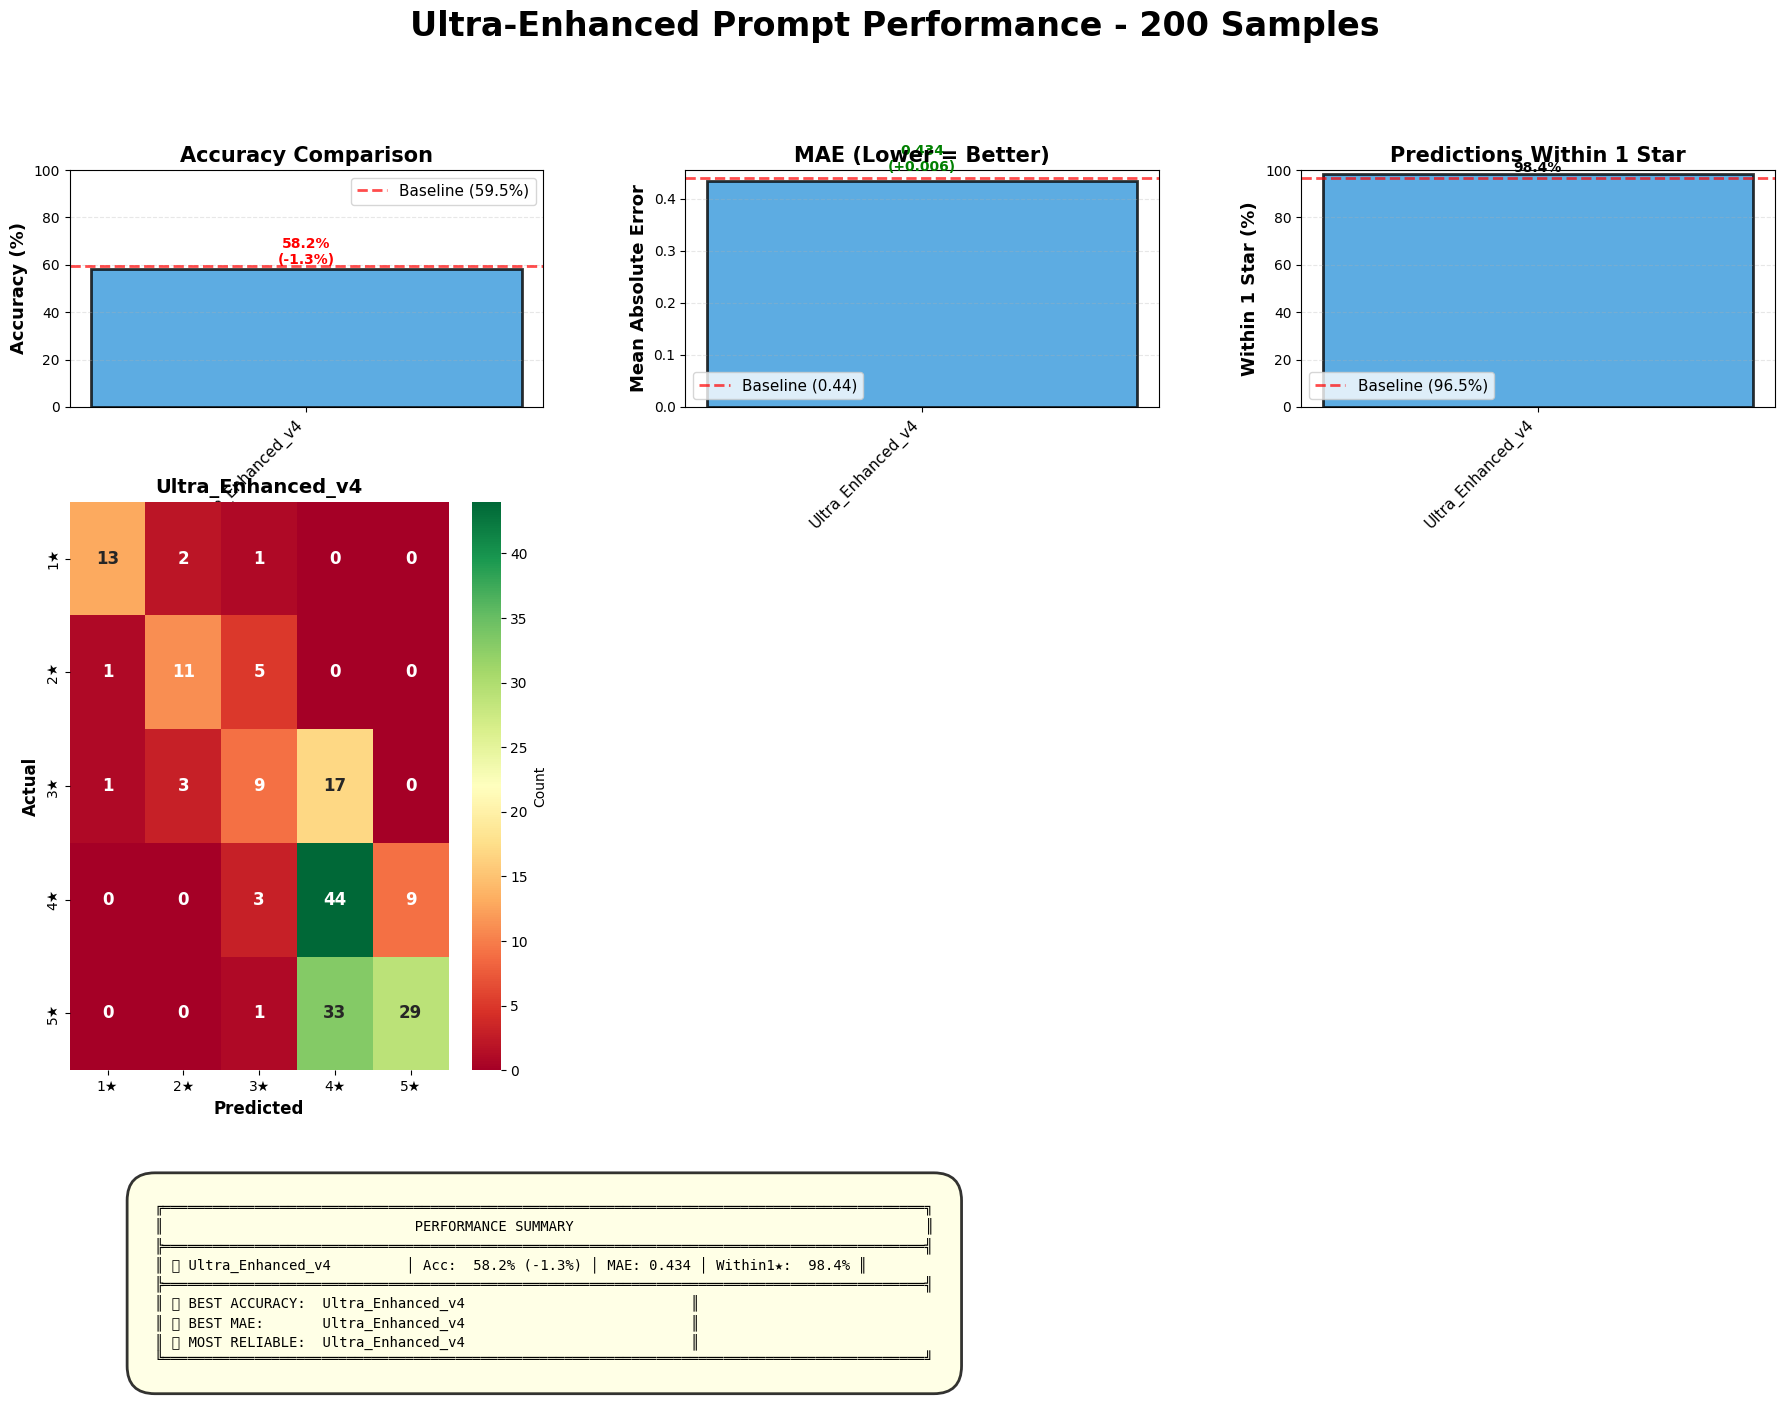


🎉 EVALUATION COMPLETE!

📈 Ultra_Enhanced_v4:
   Accuracy: 58.24% (-1.26% vs baseline)
   MAE: 0.434
   Within 1★: 98.4%

📁 Generated files:
   • Ultra_Enhanced_v4_FINAL.csv
   • Ultra_Enhanced_v4_checkpoint_*.csv
   • ultra_enhanced_comparison.png



In [62]:
if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\n\n⚠️ Interrupted by user")
    except Exception as e:
        print(f"\n\n❌ Error: {e}")
        import traceback
        traceback.print_exc()